In [27]:
import os # files IO
import numpy as np # computation 
import pandas as pd # data manipulation & .csv IO
import matplotlib
import matplotlib.pyplot as plt # visualization 
import seaborn as sns # visualization
import shutil # copy & paste files
import kagglehub # load dataset
import joblib
import warnings

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, f1_score
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from skimage.feature import hog
from scipy.ndimage import center_of_mass, shift, sobel

In [28]:
RANDOM_STATE = 42
CSV_PATH = 'CSV_FILES'
JOBLIB_PATH = 'JOBLIB_FILES'
os.makedirs(CSV_PATH, exist_ok=True)
os.makedirs(JOBLIB_PATH, exist_ok=True)

warnings.filterwarnings('ignore')

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover", "Dress",
    "Coat",
    "Sandal", "Shirt",
    "Sneaker", "Bag",
    "Ankle boot"
]

lr_params = {
    'random_state': RANDOM_STATE, 
    'n_jobs': 4,
    'max_iter': 2000,
    'C': 0.9,
}

best_variance_threshold = 0.0001

best_hog_params = {
    'orientations': 12,
    'pixels_per_cell': (4,4), 
    'cells_per_block': (2,2), 
}

# Fetch & Load Data

In [29]:
test_name = 'fashion-mnist_test.csv'
train_name = 'fashion-mnist_train.csv'

def fetch(): 
    train_path = os.path.join (os.getcwd(), train_name)
    test_path = os.path.join (os.getcwd(), test_name)
    if not (os.path.exists(train_name) and os.path.exists(test_name)): 
        source = kagglehub.dataset_download('zalando-research/fashionmnist')
        train_source = os.path.join (source, train_name)
        test_source = os.path.join (source, test_name)
        shutil.copy2 (train_source, train_path)
        shutil.copy2 (test_source, test_path)

    return train_path, test_path

def load(train_path, test_path):
    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)
    return train, test 

train_path, test_path = fetch()
data, test = load(train_path, test_path)

# Data Exploration & Experiments 

In [30]:
train_name = 'train.csv'
valid_name = 'valid.csv'
train_path = os.path.join (CSV_PATH, train_name)
valid_path = os.path.join (CSV_PATH, valid_name)

if not (os.path.exists(train_path) and os.path.exists(valid_path)): 
    train, valid = train_test_split(
        data, 
        test_size=10000, 
        shuffle = True, 
        random_state=RANDOM_STATE,
        stratify=data['label']
    )
    train.to_csv(train_path, index = False)
    valid.to_csv(valid_path, index = False)
else: 
    train, valid = pd.read_csv(train_path), pd.read_csv (valid_path) 

In [31]:
print ('train shape: ', train.shape) 
print ('valid shape: ', valid.shape) 
print ('test shape: ', test.shape)

train shape:  (50000, 785)
valid shape:  (10000, 785)
test shape:  (10000, 785)


In [32]:
x_train, y_train = train.drop('label', axis = 1).copy(), train['label'].copy()
x_valid, y_valid = valid.drop('label', axis = 1).copy(), valid['label'].copy()
x_test, y_test = test.drop('label', axis = 1).copy(), test['label'].copy()

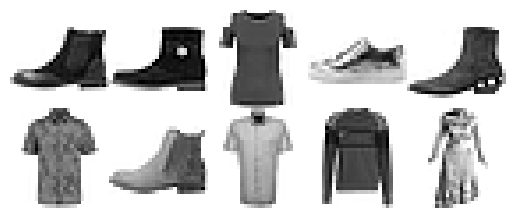

In [33]:
def plot_digits (instances): 
    image_per_row = min(len(instances), 5)
    images = [instance.reshape(28, 28) for instance in instances]
    n_rows = (len(instances) - 1) // image_per_row + 1
    row_images = []
    n_empty = n_rows * image_per_row - len(instances)
    images.append (np.zeros((28, 28 * n_empty)))  
    for row in range (n_rows): 
        rimages = images[row * image_per_row : (row + 1) * image_per_row]
        row_images.append (np.concatenate(rimages, axis = 1)) 

    image = np.concatenate (row_images, axis = 0) 
    plt.imshow (image, cmap = matplotlib.cm.binary) 
    plt.axis ('off')
plot_digits(x_train[:10].values)

# Raw Performance 

In [34]:
# Shrink train & Valid set by 5 times
train_small_path = os.path.join (CSV_PATH, 'train_small.csv')
valid_small_path = os.path.join (CSV_PATH, 'valid_small.csv')
if not (os.path.exists (train_small_path) and os.path.exists (valid_small_path)): 
    train_small, _ = train_test_split(
        train, 
        train_size = 10000, 
        random_state=RANDOM_STATE,
        shuffle=True,
        stratify=train['label'], 
    )

    valid_small, _ = train_test_split(
        valid, 
        train_size = 2000, 
        random_state=RANDOM_STATE,
        shuffle=True,
        stratify=valid['label'], 
    )

    train_small = pd.DataFrame(train_small).to_csv(train_small_path, index = False)
    valid_small = pd.DataFrame(valid_small).to_csv(valid_small_path, index = False)
    
else: 
    train_small = pd.read_csv(train_small_path)
    valid_small = pd.read_csv(valid_small_path)

x_train_small, y_train_small = train_small.drop('label', axis = 1).copy(), train_small['label'].copy()
x_valid_small, y_valid_small = valid_small.drop('label', axis = 1).copy(), valid_small['label'].copy()

In [35]:
raw_model_path = os.path.join (JOBLIB_PATH, 'Raw_Model_Compressed.joblib')

if not os.path.exists(raw_model_path): 
    # Reduce size of train & valid sets by 5 times
    print ('Training & Predicting...', end =  ' ')
    raw_model = LogisticRegression (**lr_params)
    raw_model.fit (x_train_small, y_train_small)
    joblib.dump (raw_model, raw_model_path)
    print ('DONE')
else: 
    raw_model = joblib.load(raw_model_path)
pred = raw_model.predict(x_valid_small)

f1 = f1_score (y_valid_small, pred, average='macro')
acc = accuracy_score (y_valid_small, pred)
name = 'raw_compressed_data'
results = [[name, f1, acc]]

performance_df = pd.DataFrame(results, columns = ['name', 'f1', 'acc'])
performance_df

,name,f1,acc
0,raw_compressed_data,0.766485,0.7675


# Experiment Normalizing Data

In [36]:
x_train_norm_small = x_train_small / 255.0
x_valid_norm_small = x_valid_small / 255.0

In [37]:
normalized_model_path = os.path.join (JOBLIB_PATH, 'Normalized_Model_Compressed.joblib')

if not os.path.exists(normalized_model_path): 
    model = LogisticRegression(**lr_params)
    model.fit (x_train_norm_small, y_train_small)
    joblib.dump(model, normalized_model_path)
else: 
    model = joblib.load (normalized_model_path)
    
pred = model.predict(x_valid_norm_small)
results_df = pd.DataFrame([{
    'name': 'normalized_compressed_data', 
    'f1': f1_score(y_valid_small, pred, average='macro'),
    'acc': accuracy_score(y_valid_small, pred), 
}])
performance_df = pd.concat ([performance_df, results_df], ignore_index=False)
performance_df.drop_duplicates(subset = 'name')

,name,f1,acc
0,raw_compressed_data,0.766485,0.7675
0,normalized_compressed_data,0.833389,0.8345


# Experiment Scaling Data

In [38]:
scaler = StandardScaler()
x_train_scaled_small = scaler.fit_transform (x_train_small)
x_valid_scaled_small = scaler.transform (x_valid_small)

scaled_model_path = os.path.join (JOBLIB_PATH, 'Scaled_Model_Compressed.joblib')
if not os.path.exists(scaled_model_path): 
    model = LogisticRegression(**lr_params)
    model.fit (x_train_scaled_small, y_train_small)
    joblib.dump (model, scaled_model_path)
else: 
    model = joblib.load(scaled_model_path)
pred = model.predict(x_valid_scaled_small)
performance_df = pd.concat([
    performance_df,
    pd.DataFrame([{
        'name': 'scaled_compressed_data', 
        'f1': f1_score(y_valid_small, pred, average='macro'), 
        'acc': accuracy_score(y_valid_small, pred), 
    }])
], ignore_index=False)

performance_df.drop_duplicates(subset='name')
performance_df

,name,f1,acc
0,raw_compressed_data,0.766485,0.7675
0,normalized_compressed_data,0.833389,0.8345
0,scaled_compressed_data,0.803619,0.8045


Normalization has better performance than Scaling

# Experiment Noise reduction with VarianceThreshold

In [39]:
thresholds = [0.00001, 0.0001, 0.001, 0.01]
variance_results = []

variance_result_path = os.path.join (CSV_PATH, 'variance_result.csv')
if not os.path.exists(variance_result_path): 
    for threshold in thresholds:
        pipe = Pipeline([
            ('variance', VarianceThreshold(threshold)),
            ('lr', LogisticRegression(**lr_params))
        ])
        pipe.fit(x_train_norm_small, y_train_small)
        pred = pipe.predict (x_valid_norm_small)
        
        f1 = f1_score(y_valid_small, pred, average='macro')
        acc = accuracy_score(y_valid_small, pred)
        print (threshold, ' ', f1, ' ', acc)

        variance_results.append([threshold, f1, acc])

    variance_result_df = pd.DataFrame(variance_results, columns = ['threshold', 'f1', 'acc'])
    variance_result_df.to_csv(variance_result_path, index = False)
else: 
    variance_result_df = pd.read_csv(variance_result_path)
variance_result_df

,Unnamed: 0,threshold,f1,acc
0,0,0.00001,0.838489,0.8405
1,1,0.00010,0.838684,0.8405
2,2,0.00100,0.838643,0.8405
3,3,0.01000,0.836100,0.8380


0.0001 is the best threshold

In [40]:
performance_df = pd.concat([
    performance_df, 
    pd.DataFrame([{
        'name': 'variance_threshold_compressed_data',
        'f1': variance_result_df.iloc[1]['f1'],
        'acc': variance_result_df.iloc[1]['acc'],
    }])
], ignore_index=False)
performance_df.drop_duplicates(subset = 'name')

,name,f1,acc
0,raw_compressed_data,0.766485,0.7675
0,normalized_compressed_data,0.833389,0.8345
0,scaled_compressed_data,0.803619,0.8045
0,variance_threshold_compressed_data,0.838684,0.8405


# Experiment on PCA with shrinked datasets

In [41]:
PCA_results = []
pca_result_path = os.path.join (CSV_PATH, 'PCA_result.csv')
if not os.path.exists(pca_result_path):
    for threshold in [0.85, 0.90, 0.95, 0.99]: 
        pipe = Pipeline ([
            ('variance', VarianceThreshold(best_variance_threshold)), 
            ('pca', PCA(n_components=threshold,  random_state=RANDOM_STATE,)),
            ('lr', LogisticRegression(**lr_params)), 
        ])

        pipe.fit (x_train_norm_small, y_train_small)
        pred = pipe.predict (x_valid_norm_small)
        acc = accuracy_score(y_valid_small, pred)
        f1 = f1_score(y_valid_small, pred, average='macro')

        print (threshold, ' ', f1, ' ', acc)
        PCA_results.append ([threshold, f1, acc])
    PCA_results_df = pd.DataFrame(PCA_results, columns = ['threshold', 'f1', 'acc'])
    PCA_results_df.to_csv(pca_result_path, index = False)
else:
    PCA_results_df = pd.read_csv(pca_result_path)
display(PCA_results_df)
display(performance_df)

,Unnamed: 0,threshold,f1,acc
0,0,0.85,0.824555,0.8260
1,1,0.90,0.833551,0.8350
2,2,0.95,0.837601,0.8380
3,3,0.99,0.833750,0.8355


,name,f1,acc
0,raw_compressed_data,0.766485,0.7675
0,normalized_compressed_data,0.833389,0.8345
0,scaled_compressed_data,0.803619,0.8045
0,variance_threshold_compressed_data,0.838684,0.8405


Adding PCA does not improve the performance 

# Evaluate on full train & valid sets

In [42]:
x_train_norm = x_train / 255.0
x_valid_norm = x_valid / 255.0

full_data_path = os.path.join (CSV_PATH, 'Full_Performane.csv')
full_model_path = os.path.join (JOBLIB_PATH, 'Full_Model.joblib')

if not (os.path.exists(full_data_path) and os.path.exists(full_model_path)): 
    pipe = Pipeline([
        ('variance', VarianceThreshold(best_variance_threshold)), 
        ('lr', LogisticRegression(**lr_params)), 
    ])

    if not os.path.exists(full_model_path): 
        pipe.fit (x_train_norm, y_train)
        joblib.dump (pipe, full_model_path)
    else: 
        pipe = joblib.load (full_model_path)

    pred = pipe.predict(x_valid_norm)
    f1 = f1_score(y_valid, pred, average='macro')
    acc = accuracy_score(y_valid, pred)
    
    full_performance_df = pd.DataFrame([[
        'full_data_model', 
        f1, 
        acc, 
    ]], columns = ['name', 'f1', 'acc'])

    full_performance_df.to_csv(full_data_path, index = False)
else: 
    full_performance_df = pd.read_csv(full_data_path)

In [43]:
display(full_performance_df)
display(performance_df)

,Unnamed: 0,name,f1,acc
0,0,full_data_model,0.850789,0.8519


,name,f1,acc
0,raw_compressed_data,0.766485,0.7675
0,normalized_compressed_data,0.833389,0.8345
0,scaled_compressed_data,0.803619,0.8045
0,variance_threshold_compressed_data,0.838684,0.8405


Training on full set improves performance, meaning that the model is behaving well 

In [44]:
performance_df = pd.concat([
    performance_df,
    pd.DataFrame([{
        'name': 'full_model_performance', 
        'f1': full_performance_df.iloc[0]['f1'],
        'acc': full_performance_df.iloc[0]['acc'], 
    }])
], ignore_index=False)
performance_df.drop_duplicates(subset='name')

,name,f1,acc
0,raw_compressed_data,0.766485,0.7675
0,normalized_compressed_data,0.833389,0.8345
0,scaled_compressed_data,0.803619,0.8045
0,variance_threshold_compressed_data,0.838684,0.8405
0,full_model_performance,0.850789,0.8519


In [45]:
pipe = joblib.load (full_model_path)
pred = pipe.predict(x_valid_norm)
print ('Accuracy: ', accuracy_score(y_valid, pred))
print (classification_report(y_valid, pred))

Accuracy:  0.8519
              precision    recall  f1-score   support

           0       0.78      0.80      0.79      1000
           1       0.97      0.97      0.97      1000
           2       0.76      0.77      0.76      1000
           3       0.84      0.86      0.85      1000
           4       0.77      0.81      0.79      1000
           5       0.95      0.93      0.94      1000
           6       0.64      0.57      0.61      1000
           7       0.91      0.94      0.92      1000
           8       0.94      0.94      0.94      1000
           9       0.95      0.94      0.94      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



Performance on full train - test set is apparently better: 0.8557 

On compressed sets, the accuracy was only 0.8446

# Confusion Matrix

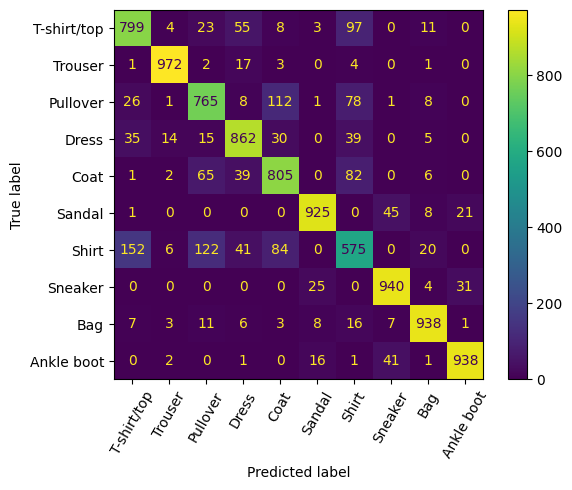

In [46]:
ConfusionMatrixDisplay.from_predictions(
    y_valid, 
    pred, 
    display_labels=class_names, 
)
plt.tick_params(axis = 'x', rotation = 60)
plt.show() 

Analysis: 
* Most confused feature is 'Shirt', classified as Tshirt/Coat, Pullover, Coat; Vice-versa
* Dress are mistaken from Tshirt/Coat, Shirt, Coat --> Weird

Conclusion: The model is mostly confused with upper-body clothes --> HOG can help

# HOG Feature Engineering

In [47]:
def extract_hog_features(X):
    images = np.asarray(X).reshape(-1, 28, 28)
    features = [
        hog(
            image,
            orientations=9,
            pixels_per_cell=(4, 4),
            cells_per_block=(2, 2),
            feature_vector=True,
        )
        for image in images
    ]
    return np.asarray(features, dtype=np.float32)


In [48]:
hog_features_path = os.path.join(JOBLIB_PATH, 'HOG_Features.joblib')

if os.path.exists(hog_features_path):
    hog_features = joblib.load(hog_features_path)
    x_train_hog = hog_features['x_train_hog']
    x_valid_hog = hog_features['x_valid_hog']
else:
    print('Extracting HOG features...', end=' ')
    x_train_hog = extract_hog_features(x_train_norm)
    x_valid_hog = extract_hog_features(x_valid_norm)
    joblib.dump(
        {
            'x_train_hog': x_train_hog,
            'x_valid_hog': x_valid_hog,
        },
        hog_features_path,
    )
    print('DONE')

print('HOG train shape:', x_train_hog.shape)
print('HOG valid shape:', x_valid_hog.shape)


HOG train shape: (50000, 1296)
HOG valid shape: (10000, 1296)


In [49]:
hog_perf_path = os.path.join(CSV_PATH, 'HOG_Features_Performance.csv')
hog_model_path = os.path.join(JOBLIB_PATH, 'HOG_Features_Model.joblib')

if os.path.exists(hog_perf_path) and os.path.exists(hog_model_path):
    hog_lr = joblib.load(hog_model_path)
    hog_results_df = pd.read_csv(hog_perf_path)
else:
    print('Training HOG Logistic Regression...', end=' ')
    hog_lr = Pipeline([
        ('variacne', VarianceThreshold(best_variance_threshold)),
        ('lr', LogisticRegression(**lr_params)), 
    ])
    hog_lr.fit(x_train_hog, y_train)
    pred_hog = hog_lr.predict(x_valid_hog)
    print('DONE')

    hog_results_df = pd.DataFrame([{
        'name': 'hog_features_performance',
        'features': x_train_hog.shape[1],
        'f1': f1_score(y_valid, pred_hog, average='macro'),
        'acc': accuracy_score(y_valid, pred_hog),
    }])
    hog_results_df.to_csv(hog_perf_path, index=False)
    joblib.dump(hog_lr, hog_model_path)

hog_results_df


,name,features,f1,acc
0,hog_features_performance,1296,0.88392,0.8842


In [50]:
performance_df = pd.concat(
    [performance_df, hog_results_df],
    ignore_index=True,
).drop_duplicates(subset='name')

performance_df

,name,f1,acc,features
0,raw_compressed_data,0.766485,0.7675,NaN
1,normalized_compressed_data,0.833389,0.8345,NaN
2,scaled_compressed_data,0.803619,0.8045,NaN
3,variance_threshold_compressed_data,0.838684,0.8405,NaN
4,full_model_performance,0.850789,0.8519,NaN
5,hog_features_performance,0.883920,0.8842,1296.0


Applying HOG improves the performance noticably

# Experiment with cleaning background + HOG

In [53]:
def threshold_background (x, threshold = 0.05): 
    x_clean = x.copy() 
    x_clean[x_clean < threshold] = 0 
    return x_clean 

x_train_clean_hog_path = os.path.join (CSV_PATH, 'x_train_clean_hog.csv')
x_valid_clean_hog_path = os.path.join (CSV_PATH, 'x_valid_clean_hog.csv')

if not (os.path.exists (x_train_clean_hog_path) and os.path.exists (x_valid_clean_hog_path)): 
    x_train_clean = threshold_background(x_train_norm)
    x_valid_clean = threshold_background(x_valid_norm)
    x_train_clean_hog = extract_hog_features(x_train_clean) 
    x_valid_clean_hog = extract_hog_features(x_valid_clean) 
    
    pd.DataFrame(x_train_clean_hog).to_csv(x_train_clean_hog_path, index = False)
    pd.DataFrame(x_valid_clean_hog).to_csv(x_valid_clean_hog_path, index = False)
else: 
    x_train_clean_hog = pd.read_csv(x_train_clean_hog_path)
    x_valid_clean_hog = pd.read_csv(x_valid_clean_hog_path)

In [54]:
hog_clean_model_path = os.path.join (JOBLIB_PATH, 'HOG_Clean_Model_Path.joblib')

if not os.path.exists(hog_clean_model_path):
    model = Pipeline([
        ('variance', VarianceThreshold(best_variance_threshold)), 
        ('lr', LogisticRegression(**lr_params)),
    ])
    
    model.fit (x_train_clean_hog, y_train)
    joblib.dump (model, hog_clean_model_path)
else:
    model = joblib.load (hog_clean_model_path)

pred = model.predict (x_valid_clean_hog)
f1 = f1_score(y_valid, pred,average='macro')
acc = accuracy_score(y_valid, pred)
hog_clean_df = pd.DataFrame([['hog_clean_data', f1, acc]], columns = ['name', 'f1', 'acc'])
display (hog_clean_df)
display (performance_df)

,name,f1,acc
0,hog_clean_data,0.858456,0.8592


,name,f1,acc,features
0,raw_compressed_data,0.766485,0.7675,NaN
1,normalized_compressed_data,0.833389,0.8345,NaN
2,scaled_compressed_data,0.803619,0.8045,NaN
3,variance_threshold_compressed_data,0.838684,0.8405,NaN
4,full_model_performance,0.850789,0.8519,NaN
5,hog_features_performance,0.883920,0.8842,1296.0


Removing the background noise with threshold = 0.05 doesn't improve the performance 

# Experiment with centering images + HOG 

In [79]:
def center_images (x: pd.DataFrame):
    images = np.asanyarray(x).reshape (-1, 28, 28) 
    centered = []

    for img in images: 
        if img.sum() == 0: 
            centered.append (img)
            continue
    
        cy, cx = center_of_mass(img)
        shift_y = 13.5 - cy 
        shift_x = 13.5 - cx 
        centered_img = shift (
            img, 
            shift = (shift_y, shift_x), 
            mode = 'constant',
            cval = 0, 
        )
        centered.append (centered_img)
        
    return np.array (centered).reshape (len (images), -1)

In [80]:
x_train_centered_hog_path = os.path.join (CSV_PATH, 'x_train_centered_hog_path.csv')
x_valid_centered_hog_path = os.path.join (CSV_PATH, 'x_valid_centered_hog_path.csv')

if not (os.path.exists(x_train_centered_hog_path) and os.path.exists(x_valid_centered_hog_path)):
    x_train_centered = center_images(x_train_norm)
    x_valid_centered = center_images(x_valid_norm)
    x_train_centered_hog = extract_hog_features(x_train_centered)
    x_valid_centered_hog = extract_hog_features(x_valid_centered)

    pd.DataFrame(x_train_centered_hog).to_csv(x_train_centered_hog_path, index = False)
    pd.DataFrame(x_valid_centered_hog).to_csv(x_valid_centered_hog_path, index = False)
else: 
    x_train_centered_hog = pd.read_csv(x_train_centered_hog_path)
    x_valid_centered_hog = pd.read_csv(x_valid_centered_hog_path)

In [81]:
centered_hog_model_path = os.path.join (JOBLIB_PATH, 'Centered_HOG_Model.joblib')
if not os.path.exists(centered_hog_model_path):
    model = Pipeline ([
        ('variance', VarianceThreshold(best_variance_threshold)), 
        ('lr', LogisticRegression (**lr_params)), 
    ])

    model.fit (x_train_centered_hog, y_train)
    joblib.dump (model, centered_hog_model_path)
else: 
    model = joblib.load (centered_hog_model_path)
pred = model.predict (x_valid_centered_hog)
f1 = f1_score(y_valid, pred, average='macro')
acc = accuracy_score(y_valid, pred)
Clean_HOG_df = pd.DataFrame([['centered_hog_data', f1, acc]], columns=['name', 'f1', 'acc']) 
display(Clean_HOG_df) 
display(performance_df) 

,name,f1,acc
0,centered_hog_data,0.880115,0.8807


,name,f1,acc,features
0,raw_compressed_data,0.766485,0.7675,NaN
1,normalized_compressed_data,0.833389,0.8345,NaN
2,scaled_compressed_data,0.803619,0.8045,NaN
3,variance_threshold_compressed_data,0.838684,0.8405,NaN
4,full_model_performance,0.850789,0.8519,NaN
5,hog_features_performance,0.883920,0.8842,1296.0
0,Tuned_HOG_Data,0.885798,0.8863,NaN


Centering image doesn't have any impact on performance 

# Experimenting on HOG + Sobel Features

In [58]:
def extract_sobel_features (x: pd.DataFrame): 
    images = np.array(x).reshape (-1, 28, 28) 
    features = []

    for img in images: 
        sx = sobel (img, axis = 1)
        sy = sobel (img, axis = 0) 
        magnitude = np.hypot (sx, sy)
        features.append (magnitude.reshape (-1)) 

    return np.array (features, dtype = float)

In [59]:
x_train_sobel = extract_sobel_features(x_train_norm)
x_valid_sobel = extract_sobel_features(x_valid_norm) 
x_train_sobel_HOG = np.hstack([x_train_hog, x_train_sobel])
x_valid_sobel_HOG = np.hstack([x_valid_hog, x_valid_sobel])

In [60]:
HOG_Sobel_model_path = os.path.join (JOBLIB_PATH, 'HOG_Sobel_Model.joblib')
if not os.path.exists(HOG_Sobel_model_path): 
    model = Pipeline([
        ('variance', VarianceThreshold(best_variance_threshold)), 
        ('lr', LogisticRegression(**lr_params)),
    ])

    model.fit (x_train_sobel_HOG, y_train)
    pred = model.predict (x_valid_sobel_HOG)
    joblib.dump (model, HOG_Sobel_model_path) 
else: 
    model = joblib.load (HOG_Sobel_model_path) 

pred = model.predict(x_valid_sobel_HOG)
f1 = f1_score(y_valid, pred, average='macro')
acc = accuracy_score(y_valid, pred)
HOG_Sobel_df = pd.DataFrame([['HOG_Sobel_Data', f1, acc]], columns = ['name', 'f1', 'acc'])

display(HOG_Sobel_df)
display(performance_df) 

,name,f1,acc
0,HOG_Sobel_Data,0.88082,0.8811


,name,f1,acc,features
0,raw_compressed_data,0.766485,0.7675,NaN
1,normalized_compressed_data,0.833389,0.8345,NaN
2,scaled_compressed_data,0.803619,0.8045,NaN
3,variance_threshold_compressed_data,0.838684,0.8405,NaN
4,full_model_performance,0.850789,0.8519,NaN
5,hog_features_performance,0.883920,0.8842,1296.0


Combining Sobel with HOG doesn't improve the performance 

# Experiment having PCA to reduce HOG features 

In [61]:
x_train_hog_small = extract_hog_features(x_train_norm_small)
x_valid_hog_small = extract_hog_features(x_valid_norm_small)

In [62]:
HOG_PCA_data_path = os.path.join (CSV_PATH, 'HOG_PCA_Data.csv')
HOG_PCA_results = []

if not os.path.exists(HOG_PCA_data_path):
    for threshold in [0.85, 0.90, 0.95, 0.99]: 
        pipe = Pipeline ([
            ('variance', VarianceThreshold(best_variance_threshold)), 
            ('PCA', PCA(threshold)), 
            ('lr', LogisticRegression (**lr_params)), 
        ])

        pipe.fit (x_train_hog_small, y_train_small)
        pred = pipe.predict (x_valid_hog_small)
        f1 = f1_score (y_valid_small, pred, average='macro')
        acc = accuracy_score(y_valid_small, pred)
        print (threshold, ' ', f1, ' ', acc)
        
        HOG_PCA_results.append ([threshold, f1, acc]) 
    HOG_PCA_results_df = pd.DataFrame(HOG_PCA_results, columns = ['threshold', 'f1', 'acc'])
    HOG_PCA_results_df.to_csv(HOG_PCA_data_path, index=False)
else: 
    HOG_PCA_results_df = pd.read_csv(HOG_PCA_data_path)
display(HOG_PCA_results_df)

,Unnamed: 0,threshold,f1,acc
0,0,0.85,0.860057,0.8610
1,1,0.90,0.854189,0.8555
2,2,0.95,0.860724,0.8620
3,3,0.99,0.858654,0.8600


On compressed set, 0.95 has the best performance

In [63]:
HOG_PCA_Model_path = os.path.join (JOBLIB_PATH, 'HOG_PCA_model.joblib')
if not os.path.exists(HOG_PCA_Model_path): 
    model = Pipeline([
        ('variance', VarianceThreshold(best_variance_threshold)), 
        ('PCA', PCA(0.95)), 
        ('lr', LogisticRegression(**lr_params)), 
    ])

    model.fit (x_train_hog, y_train)
    joblib.dump(model, HOG_PCA_Model_path)
else: 
    model = joblib.load (HOG_PCA_Model_path)

pred = model.predict (x_valid_hog)
f1 = f1_score(y_valid, pred, average='macro')
acc = accuracy_score(y_valid, pred)
HOG_PCA_Model_df = pd.DataFrame([['HOG_PCA_Full_Model', f1, acc]], columns = ['name', 'f1', 'acc'])
display(HOG_PCA_Model_df)
display(performance_df)

,name,f1,acc
0,HOG_PCA_Full_Model,0.878406,0.8789


,name,f1,acc,features
0,raw_compressed_data,0.766485,0.7675,NaN
1,normalized_compressed_data,0.833389,0.8345,NaN
2,scaled_compressed_data,0.803619,0.8045,NaN
3,variance_threshold_compressed_data,0.838684,0.8405,NaN
4,full_model_performance,0.850789,0.8519,NaN
5,hog_features_performance,0.883920,0.8842,1296.0


Adding PCA on HOG doesn't improve the performance

### The best pipeline is: Normalization --> Variance Threshold --> HOG

# Data Augmentation 

### Experiment Shifting Images

In [64]:
def shift_images (x: pd.DataFrame, y: pd.Series): 
    images = np.asarray(x).reshape (-1, 28, 28)
    shifted_images = []
    shifted_labels = []

    shifts = [(0,0), (0,2), (2,0), (0, -2), (-2, 0)]
    for img, label in zip (images, y): 
        for shift_value in shifts:
            shifted_img = shift (
                img, 
                shift = shift_value, 
                mode = 'constant', 
                cval = 0,
            )
            shifted_images.append (shifted_img)
            shifted_labels.append (label) 
    return (
        np.asarray(shifted_images).reshape (len(shifted_images), -1),
        np.asarray(shifted_labels)
    )

In [65]:
x_train_shifted_HOG_path = os.path.join (CSV_PATH, 'x_train_shifted_HOG.csv')
y_train_shifted_HOG_path = os.path.join (CSV_PATH, 'y_train_shifted_HOG.csv')
if not (os.path.exists (x_train_shifted_HOG_path) and 
        os.path.exists (y_train_shifted_HOG_path)):
    
    print ('Shifting images...', end = ' ')
    x_train_shifted, y_train_shifted_HOG = shift_images (x_train_norm, y_train)
    print ('DONE')
    print ('Extracting HOG features....', end = ' ')
    x_train_shifted_HOG = extract_hog_features(x_train_shifted)
    print ('DONE')
    print ('Converting datasets to .csv files', end = ' ')
    pd.DataFrame(x_train_shifted_HOG).to_csv (x_train_shifted_HOG_path, index = False)
    pd.DataFrame(y_train_shifted_HOG).to_csv (y_train_shifted_HOG_path, index = False)
    print ('DONE')
else: 
    print ('Loading x_train_shifted_HOG...', end = ' ')
    x_train_shifted_HOG = pd.read_csv(x_train_shifted_HOG_path).to_numpy()
    print ('DONE')
    print ('Loading y_train_shifted_HOG...', end = ' ')
    y_train_shifted_HOG = pd.read_csv(y_train_shifted_HOG_path).to_numpy()
    print ('DONE')

Loading x_train_shifted_HOG... DONE
Loading y_train_shifted_HOG... DONE


In [66]:
HOG_Shifted_Model_Path = os.path.join (JOBLIB_PATH, 'HOG_Shifted_Model.joblib')
if not os.path.exists (HOG_Shifted_Model_Path): 
    model = Pipeline ([
        ('variance', VarianceThreshold (best_variance_threshold)), 
        ('lr', LogisticRegression (**lr_params)),
    ])
    model.fit (x_train_shifted_HOG, y_train_shifted_HOG)
    joblib.dump (model, HOG_Shifted_Model_Path)
else: 
    model = joblib.load (HOG_Shifted_Model_Path)

pred = model.predict (x_valid_hog)
f1 = f1_score (y_valid, pred, average = 'macro')
acc = accuracy_score(y_valid, pred) 

HOG_Shifted_Data_df = pd.DataFrame ([['HOG_Shifted_Data', f1, acc]], columns = ['name', 'f1', 'acc']) 
display(HOG_Shifted_Data_df)
display(performance_df)  

,name,f1,acc
0,HOG_Shifted_Data,0.876291,0.8772


,name,f1,acc,features
0,raw_compressed_data,0.766485,0.7675,NaN
1,normalized_compressed_data,0.833389,0.8345,NaN
2,scaled_compressed_data,0.803619,0.8045,NaN
3,variance_threshold_compressed_data,0.838684,0.8405,NaN
4,full_model_performance,0.850789,0.8519,NaN
5,hog_features_performance,0.883920,0.8842,1296.0


Shifting data does not improve the performance of the model 

# Fine tune HOG variables 

In [67]:
def extract_hog_features_tuned(
    X, orientations, pixels_per_cell, cells_per_block
):
    images = np.asarray(X).reshape(-1, 28, 28)
    features = [
        hog(
            image,
            orientations=orientations,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            block_norm='L2-Hys',
            feature_vector=True,
        )
        for image in images
    ]
    return np.asarray(features, dtype=np.float32)


In [68]:
hog_configs = [
    {'orientations': 6, 'pixels_per_cell': (4, 4), 'cells_per_block': (2, 2)},
    {'orientations': 9, 'pixels_per_cell': (4, 4), 'cells_per_block': (2, 2)},
    {'orientations': 12, 'pixels_per_cell': (4, 4), 'cells_per_block': (2, 2)},
    {'orientations': 9, 'pixels_per_cell': (7, 7), 'cells_per_block': (2, 2)},
    {'orientations': 12, 'pixels_per_cell': (7, 7), 'cells_per_block': (2, 2)},
    {'orientations': 9, 'pixels_per_cell': (14, 14), 'cells_per_block': (1, 1)},
]

In [69]:
hog_tuning_path = os.path.join(CSV_PATH, 'HOG_Tuning_Results.csv')

if os.path.exists(hog_tuning_path):
    hog_tuning_df = pd.read_csv(hog_tuning_path)
else:
    hog_tuning_results = []

    for config in hog_configs:
        name = (
            f"hog_o{config['orientations']}_"
            f"ppc{config['pixels_per_cell'][0]}x{config['pixels_per_cell'][1]}_"
            f"cpb{config['cells_per_block'][0]}x{config['cells_per_block'][1]}"
        )

        print(f'Running {name}...', end=' ')
        x_train_hog_tuned = extract_hog_features_tuned(x_train_norm, **config)
        x_valid_hog_tuned = extract_hog_features_tuned(x_valid_norm, **config)

        model = Pipeline([
            ('variance', VarianceThreshold(best_variance_threshold)), 
            ('lr', LogisticRegression(**lr_params)), 
        ])

        model.fit(x_train_hog_tuned, y_train)
        pred = model.predict(x_valid_hog_tuned)

        acc = accuracy_score(y_valid, pred)
        f1 = f1_score(y_valid, pred, average='macro')

        hog_tuning_results.append({
            'name': name,
            'orientations': config['orientations'],
            'pixels_per_cell': str(config['pixels_per_cell']),
            'cells_per_block': str(config['cells_per_block']),
            'features': x_train_hog_tuned.shape[1],
            'f1': f1,
            'acc': acc,
        })
        print('DONE')

    hog_tuning_df = pd.DataFrame(hog_tuning_results)
    hog_tuning_df.to_csv(hog_tuning_path, index=False)

display(hog_tuning_df)
display(performance_df)

,name,orientations,pixels_per_cell,cells_per_block,features,f1,acc
0,hog_o6_ppc4x4_cpb2x2,6,"(4, 4)","(2, 2)",864,0.882834,0.8833
1,hog_o9_ppc4x4_cpb2x2,9,"(4, 4)","(2, 2)",1296,0.883920,0.8842
2,hog_o12_ppc4x4_cpb2x2,12,"(4, 4)","(2, 2)",1728,0.885943,0.8864
3,hog_o9_ppc7x7_cpb2x2,9,"(7, 7)","(2, 2)",324,0.853038,0.8536
4,hog_o12_ppc7x7_cpb2x2,12,"(7, 7)","(2, 2)",432,0.854107,0.8545
5,hog_o9_ppc14x14_cpb1x1,9,"(14, 14)","(1, 1)",36,0.696981,0.6988


,name,f1,acc,features
0,raw_compressed_data,0.766485,0.7675,NaN
1,normalized_compressed_data,0.833389,0.8345,NaN
2,scaled_compressed_data,0.803619,0.8045,NaN
3,variance_threshold_compressed_data,0.838684,0.8405,NaN
4,full_model_performance,0.850789,0.8519,NaN
5,hog_features_performance,0.883920,0.8842,1296.0


The performance of the pipeline is best with variables:
* orientations = 12
* pixels_per_cell = (4,4)
* cells_per_block = (2,2)

# Experiment fine-tuned HOG on full data

In [70]:
def extract_tuned_HOG(x: pd.DataFrame): 
    images = np.asarray(x).reshape (-1, 28, 28)
    features = [
        hog (image, **best_hog_params)
        for image in images
    ]
    return np.asarray (features, dtype = float) 

def normalize (x: pd.DataFrame): 
    x = x.copy()
    return x / 255.0

hog_transformer = FunctionTransformer(extract_tuned_HOG)
normalize_transformer = FunctionTransformer(normalize)

In [71]:
Tuned_HOG_Full_Model_path = os.path.join (JOBLIB_PATH, 'Tuned_HOG_Model.joblib')

if not os.path.exists(Tuned_HOG_Full_Model_path): 
    model = Pipeline([
        ('normalize', normalize_transformer), 
        ('hog', hog_transformer), 
        ('variance', VarianceThreshold(best_variance_threshold)), 
        ('lr', LogisticRegression(**lr_params)), 
    ])

    model.fit (x_train, y_train)
    joblib.dump (model, Tuned_HOG_Full_Model_path)
else: 
    model = joblib.load (Tuned_HOG_Full_Model_path)

pred = model.predict (x_valid)
f1 = f1_score(y_valid, pred, average='macro') 
acc = accuracy_score(y_valid, pred)
Tuned_HOG_df = pd.DataFrame([['Tuned_HOG_Data', f1, acc]], columns = ['name', 'f1', 'acc'])

In [72]:
display (Tuned_HOG_df)
display(performance_df)

,name,f1,acc
0,Tuned_HOG_Data,0.885798,0.8863


,name,f1,acc,features
0,raw_compressed_data,0.766485,0.7675,NaN
1,normalized_compressed_data,0.833389,0.8345,NaN
2,scaled_compressed_data,0.803619,0.8045,NaN
3,variance_threshold_compressed_data,0.838684,0.8405,NaN
4,full_model_performance,0.850789,0.8519,NaN
5,hog_features_performance,0.883920,0.8842,1296.0


In [73]:
performance_df = pd.concat([
    performance_df, 
    Tuned_HOG_df, 
], ignore_index=False).drop_duplicates(subset = ['name'])
performance_df

,name,f1,acc,features
0,raw_compressed_data,0.766485,0.7675,NaN
1,normalized_compressed_data,0.833389,0.8345,NaN
2,scaled_compressed_data,0.803619,0.8045,NaN
3,variance_threshold_compressed_data,0.838684,0.8405,NaN
4,full_model_performance,0.850789,0.8519,NaN
5,hog_features_performance,0.883920,0.8842,1296.0
0,Tuned_HOG_Data,0.885798,0.8863,NaN


In [74]:
print ('Accuracy: ', acc); print() 
print (classification_report (y_valid, pred))


Accuracy:  0.8863

              precision    recall  f1-score   support

           0       0.83      0.84      0.84      1000
           1       0.97      0.98      0.98      1000
           2       0.83      0.83      0.83      1000
           3       0.88      0.89      0.88      1000
           4       0.79      0.83      0.81      1000
           5       0.96      0.96      0.96      1000
           6       0.71      0.66      0.68      1000
           7       0.94      0.95      0.94      1000
           8       0.98      0.97      0.98      1000
           9       0.97      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



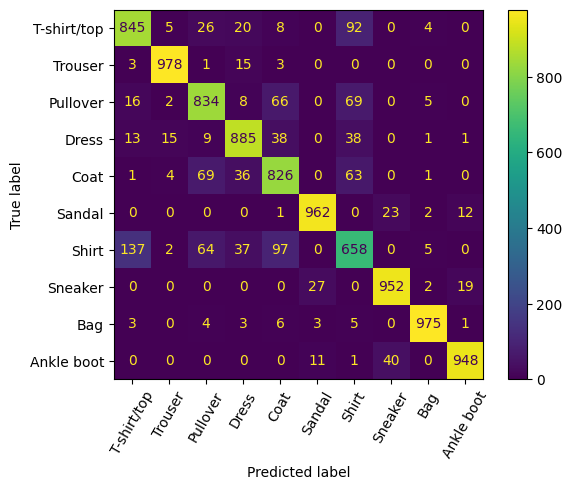

In [75]:
ConfusionMatrixDisplay.from_predictions(y_valid, pred, display_labels=class_names)
plt.tick_params(axis = 'x', rotation = 60)
plt.show() 